# Clinical Biomarker Feature Extraction
## Wrist Accelerometer Data — Stroke Motor Recovery

This notebook processes 24-hour wrist accelerometer recordings from stroke survivors and healthy controls. It extracts kinematic features from 3-second sliding windows, aggregates them per clinical visit, and produces a feature matrix ready for biomarker analysis.

**Dataset:** 61 subjects (57 stroke survivors across up to 8 visits, 4 healthy controls), 198 total clinical visits.

**Pipeline:**
1. Load accelerometer windows and clinical scores
2. Extract 38 kinematic features per window (acceleration, velocity, jerk, position)
3. Aggregate to 228 features per visit (6 summary statistics per raw feature)
4. Split into even/odd 30-minute blocks for test-retest reliability analysis
5. Save feature matrix, run baseline classification, visualize embedding structure

---
## 0 — Setup

In [16]:
import subprocess, sys
for pkg in ['umap-learn', 'seaborn', 'scikit-learn']:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', pkg])

In [17]:
import os, sys, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from scipy.stats import skew, kurtosis, spearmanr
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, roc_auc_score, classification_report

warnings.filterwarnings('ignore')
%matplotlib inline

DATA_DIR    = 'data'
OUTPUT_PATH = 'features/biopm_features.npz'
FIGURES_DIR = 'results/figures'
METRICS_DIR = 'results/metrics'

for d in ['features', FIGURES_DIR, METRICS_DIR]:
    os.makedirs(d, exist_ok=True)

def progress(current, total, prefix='', width=40, start_time=None):
    pct    = current / total
    filled = int(width * pct)
    bar    = '#' * filled + '-' * (width - filled)
    eta    = ''
    if start_time and current > 0:
        elapsed   = time.time() - start_time
        remaining = (total - current) / (current / elapsed)
        eta = f'  ETA {remaining:.0f}s'
    sys.stdout.write(f'\r{prefix} [{bar}] {current}/{total} ({pct*100:.0f}%){eta}')
    sys.stdout.flush()
    if current == total:
        print()

---
## 1 — Load Data

`clinical_scores.npz` — dictionary keyed by `(subject_id, week)`, values contain `.ARAT` and `.FMA` scores.

`windows.npz` — 587,046 sliding window objects (3 seconds each at 30 Hz). Each window has `.acc`, `.vel`, `.pos`, `.jerk` arrays of shape `(90, 3)` and `.subject`, `.week`, `.start_idx` metadata.

Healthy controls were assigned maximum clinical scores (ARAT=57, FMA=66) without being formally tested. This is how we identify group membership.

In [ ]:
clin = np.load(os.path.join(DATA_DIR, 'clinical_scores.npz'), allow_pickle=True)
clinical_scores = clin['clinical_scores'].item()

# Identify healthy vs stroke
all_subjects = sorted(set(k[0] for k in clinical_scores.keys()))
healthy_subjects = set()
for subj in all_subjects:
    key = next(k for k in clinical_scores if k[0] == subj)
    cs  = clinical_scores[key]
    if cs.ARAT == 57 and cs.FMA == 66:
        healthy_subjects.add(subj)

print(f'Clinical visits  : {len(clinical_scores)}')
print(f'Total subjects   : {len(all_subjects)}')
print(f'Healthy controls : {len(healthy_subjects)}')
print(f'Stroke survivors : {len(all_subjects) - len(healthy_subjects)}')

Clinical visits  : 223
Total subjects   : 61
Healthy controls : 4
Stroke survivors : 57


In [19]:
# windows.npz is large (~2GB in memory after deserialization)
print('Loading windows.npz...')
t0 = time.time()
data = np.load(os.path.join(DATA_DIR, 'windows.npz'), allow_pickle=True)
windows = data['windows']
print(f'Loaded {len(windows):,} windows in {time.time()-t0:.0f}s')
print(f'Window: acc={windows[0].acc.shape}, {windows[0].acc.shape[0]/windows[0].sample_rate:.0f}s at {windows[0].sample_rate}Hz')

Loading windows.npz...
Loaded 587,046 windows in 132s
Window: acc=(90, 3), 3s at 30Hz


---
## 2 — Feature Extraction

**Per window (38 raw features):**  
For each of acceleration, velocity, and jerk: mean, std, max per axis (X/Y/Z) plus magnitude = 12 features each.  
For position: total displacement and cumulative path length = 2 features.  
Total: 3 × 12 + 2 = 38.

**Per visit (228 aggregated features):**  
Each of the 38 raw features is summarized across all windows in a visit using 6 statistics: mean, std, IQR, 10th percentile, 50th percentile, 90th percentile.  
Total: 38 × 6 = 228.

In [ ]:
def extract_features_from_wnd(wnd):
    """Extract 38 kinematic features from a single 3-second window."""
    feats, names = [], []
    axes = ['X', 'Y', 'Z']

    acc  = wnd.acc
    vel  = wnd.vel
    pos  = wnd.pos
    jerk = wnd.jerk

    # Acceleration per axis
    for i, ax in enumerate(axes):
        feats += [np.mean(acc[:,i]), np.std(acc[:,i]), np.max(acc[:,i])]
        names += [f'{ax}_acc_mean', f'{ax}_acc_std', f'{ax}_acc_max']

    # Acceleration magnitude
    acc_mag = np.linalg.norm(acc, axis=1)
    feats += [np.mean(acc_mag), np.std(acc_mag), np.max(acc_mag)]
    names += ['acc_mag_mean', 'acc_mag_std', 'acc_mag_max']

    # Velocity per axis
    for i, ax in enumerate(axes):
        feats += [np.mean(vel[:,i]), np.std(vel[:,i]), np.max(vel[:,i])]
        names += [f'{ax}_vel_mean', f'{ax}_vel_std', f'{ax}_vel_max']

    # Velocity magnitude
    vel_mag = np.linalg.norm(vel, axis=1)
    feats += [np.mean(vel_mag), np.std(vel_mag), np.max(vel_mag)]
    names += ['vel_mag_mean', 'vel_mag_std', 'vel_mag_max']

    # Jerk per axis
    for i, ax in enumerate(axes):
        feats += [np.mean(jerk[:,i]), np.std(jerk[:,i]), np.max(jerk[:,i])]
        names += [f'{ax}_jerk_mean', f'{ax}_jerk_std', f'{ax}_jerk_max']

    # Jerk magnitude
    jerk_mag = np.linalg.norm(jerk, axis=1)
    feats += [np.mean(jerk_mag), np.std(jerk_mag), np.max(jerk_mag)]
    names += ['jerk_mag_mean', 'jerk_mag_std', 'jerk_mag_max']

    # Position: displacement and path length
    displacement = float(np.linalg.norm(pos[-1] - pos[0]))
    path_length  = float(np.sum(np.linalg.norm(np.diff(pos, axis=0), axis=1)))
    feats += [displacement, path_length]
    names += ['displacement', 'path_length']

    return np.array(feats, dtype=np.float32), names


def calc_aggregates(feats_matrix, feat_names):
    """
    Aggregate a (N_windows, N_raw_feats) matrix into one vector
    using 6 summary statistics per feature:
      mean, std, IQR (q75-q25), p10, p50, p90
    Returns (6*N_raw_feats,) array and corresponding names.
    """
    p10, p25, p50, p75, p90 = np.percentile(feats_matrix, [10, 25, 50, 75, 90], axis=0)
    mean_v = feats_matrix.mean(axis=0)
    std_v  = feats_matrix.std(axis=0)
    iqr_v  = p75 - p25

    agg_feats, agg_names = [], []
    for i, name in enumerate(feat_names):
        agg_feats += [mean_v[i], std_v[i], iqr_v[i], p10[i], p50[i], p90[i]]
        agg_names += [f'{name}_mean', f'{name}_std', f'{name}_iqr',
                      f'{name}_p10',  f'{name}_p50', f'{name}_p90']

    return np.array(agg_feats, dtype=np.float32), agg_names


# Verify shapes before running the full extraction
test_feats, test_names = extract_features_from_wnd(windows[0])
test_agg, _ = calc_aggregates(np.stack([test_feats, test_feats]), test_names)
assert len(test_feats) == 38,  f'Expected 38 raw features, got {len(test_feats)}'
assert len(test_agg)   == 228, f'Expected 228 aggregated features, got {len(test_agg)}'
print('Feature functions verified: 38 raw → 228 aggregated')

Feature functions verified: 38 raw → 228 aggregated


In [21]:
# Extract features from all 587,046 windows (~3 min)
feat_dict  = defaultdict(list)
feat_names = None
t0 = time.time()

for i, wnd in enumerate(windows):
    feats, names = extract_features_from_wnd(wnd)
    feat_dict[(wnd.subject, wnd.week)].append(feats)
    if feat_names is None:
        feat_names = names
    if (i + 1) % 50000 == 0 or (i + 1) == len(windows):
        progress(i + 1, len(windows), prefix='Extracting', start_time=t0)

print(f'Done in {time.time()-t0:.0f}s  |  {len(feat_dict)} unique visits')

Extracting [########################################] 587046/587046 (100%)  ETA 0s
Done in 141s  |  198 unique visits


In [22]:
# Aggregate window-level features to visit-level (one vector per subject-visit)
t0 = time.time()
visits = sorted(feat_dict.keys())

all_features, all_arat, all_fma = [], [], []
all_subjects, all_weeks = [], []
feature_names_agg = None

for i, key in enumerate(visits):
    subj, week = key
    cs = clinical_scores.get(key)
    if cs is None:
        continue

    agg, agg_names = calc_aggregates(np.stack(feat_dict[key]), feat_names)
    all_features.append(agg)
    all_arat.append(cs.ARAT)
    all_fma.append(cs.FMA)
    all_subjects.append(subj)
    all_weeks.append(week)
    if feature_names_agg is None:
        feature_names_agg = agg_names

    if (i + 1) % 20 == 0 or (i + 1) == len(visits):
        progress(i + 1, len(visits), prefix='Aggregating', start_time=t0)

features = np.array(all_features, dtype=np.float32)
ARAT     = np.array(all_arat,     dtype=np.float32)
FMA      = np.array(all_fma,      dtype=np.float32)
subjects = np.array(all_subjects)
weeks    = np.array(all_weeks, dtype=np.int32)

# Group label: healthy controls have ARAT=57 and FMA=66 (assigned at max without testing)
labels = np.array([0 if (a == 57 and f == 66) else 1
                   for a, f in zip(all_arat, all_fma)], dtype=np.int32)

unique_subjects = sorted(set(subjects.tolist()))
subj_to_int     = {s: i for i, s in enumerate(unique_subjects)}
pids = np.array([subj_to_int[s] for s in subjects], dtype=np.int32)

print(f'Feature matrix : {features.shape}')
print(f'Healthy        : {(labels==0).sum()} visits')
print(f'Stroke         : {(labels==1).sum()} visits')
print(f'Subjects       : {len(unique_subjects)}')

Aggregating [########################################] 198/198 (100%)  ETA 0s
Feature matrix : (198, 228)
Healthy        : 4 visits
Stroke         : 194 visits
Subjects       : 36


---
## 3 — Test-Retest Reliability Split

To assess the reliability of extracted features, we split each subject's 24-hour recording into two pseudo-replicate sets using alternating 30-minute blocks.

Even blocks: minutes 0–30, 60–90, 120–150, ...  
Odd blocks: minutes 30–60, 90–120, 150–180, ...

Features extracted from these two splits (`features_even`, `features_odd`) can be used to compute ICC (Intraclass Correlation Coefficient) as a measure of test-retest reliability. High ICC (>0.75) indicates a feature is stable and reliable across time within the same subject-visit.

In [23]:
# 30 minutes at 30Hz = 54,000 samples
BLOCK_SIZE = 30 * 60 * 30

t0 = time.time()
even_windows, odd_windows = [], []

for i, wnd in enumerate(windows):
    block = wnd.start_idx // BLOCK_SIZE
    if block % 2 == 0:
        even_windows.append(wnd)
    else:
        odd_windows.append(wnd)
    if (i + 1) % 50000 == 0:
        progress(i + 1, len(windows), prefix='Splitting', start_time=t0)

progress(len(windows), len(windows), prefix='Splitting', start_time=t0)
even_windows = np.array(even_windows)
odd_windows  = np.array(odd_windows)

print(f'Done in {time.time()-t0:.0f}s')
print(f'Even : {len(even_windows):,} windows')
print(f'Odd  : {len(odd_windows):,} windows')

Splitting [########################################] 587046/587046 (100%)  ETA 0s
Done in 25s
Even : 294,723 windows
Odd  : 292,323 windows


In [24]:
def extract_features_for_split(window_group, label=''):
    """
    Extract and aggregate features for a subset of windows.
    Output is aligned to the same visit order as the main features matrix.
    Visits with fewer than 2 windows in this split are zeroed out.
    """
    t0 = time.time()
    fd, fn = defaultdict(list), None

    for i, wnd in enumerate(window_group):
        feats, names = extract_features_from_wnd(wnd)
        fd[(wnd.subject, wnd.week)].append(feats)
        if fn is None:
            fn = names
        if (i + 1) % 50000 == 0 or (i + 1) == len(window_group):
            progress(i + 1, len(window_group), prefix=f'  {label}', start_time=t0)

    visit_idx = {v: i for i, v in enumerate(visits)}
    result = np.zeros((len(visits), len(feature_names_agg)), dtype=np.float32)

    for key, feat_list in fd.items():
        if key not in visit_idx or len(feat_list) < 2:
            continue
        agg, _ = calc_aggregates(np.stack(feat_list), fn)
        result[visit_idx[key]] = agg

    print(f'  Done in {time.time()-t0:.0f}s')
    return result


features_even = extract_features_for_split(even_windows, 'even')
features_odd  = extract_features_for_split(odd_windows,  'odd')

print(f'features_even : {features_even.shape}')
print(f'features_odd  : {features_odd.shape}')

  even [########################################] 294723/294723 (100%)  ETA 0s
  Done in 74s
  odd [########################################] 292323/292323 (100%)  ETA 0s
  Done in 74s
features_even : (198, 228)
features_odd  : (198, 228)


---
## 4 — Save and Verify

Saves `features/biopm_features.npz` with all arrays needed for downstream biomarker analysis.

| Key | Shape | Description |
|---|---|---|
| `features` | (198, 228) | Main feature matrix, one row per visit |
| `features_even` | (198, 228) | Even 30-min blocks (for ICC) |
| `features_odd` | (198, 228) | Odd 30-min blocks (for ICC) |
| `feature_names` | (228,) | Name of each feature column |
| `labels` | (198,) | 0 = healthy control, 1 = stroke survivor |
| `pids` | (198,) | Integer subject ID (use as LOSO group variable) |
| `arat` | (198,) | ARAT clinical score (0–57) |
| `fma` | (198,) | FMA-UE clinical score (0–66) |
| `subjects` | (198,) | Original subject identifiers |
| `weeks` | (198,) | Clinical visit week number |

In [25]:
np.savez(
    OUTPUT_PATH,
    features      = features,
    features_even = features_even,
    features_odd  = features_odd,
    feature_names = np.array(feature_names_agg),
    labels        = labels,
    pids          = pids,
    arat          = ARAT,
    fma           = FMA,
    subjects      = subjects,
    weeks         = weeks,
)

d = np.load(OUTPUT_PATH, allow_pickle=True)
checks = [
    ('features shape (198, 228)',  d['features'].shape == (198, 228)),
    ('features_even shape OK',     d['features_even'].shape == (198, 228)),
    ('features_odd shape OK',      d['features_odd'].shape == (198, 228)),
    ('No NaNs in features',        not np.isnan(d['features']).any()),
    ('Labels are binary (0/1)',    set(d['labels'].tolist()).issubset({0, 1})),
    ('Both classes present',       len(set(d['labels'].tolist())) == 2),
    ('Clinical scores present',    all(k in d for k in ['arat', 'fma', 'weeks'])),
    ('228 feature names',          len(d['feature_names']) == 228),
]

all_ok = True
for name, result in checks:
    print(f'  [{"OK" if result else "FAIL"}]  {name}')
    if not result:
        all_ok = False

print()
print('PASSED' if all_ok else 'FAILED — check errors above')

  [OK]  features shape (198, 228)
  [OK]  features_even shape OK
  [OK]  features_odd shape OK
  [OK]  No NaNs in features
  [OK]  Labels are binary (0/1)
  [OK]  Both classes present
  [OK]  Clinical scores present
  [OK]  228 feature names

PASSED


---
## 5 — Baseline Classification

Leave-One-Subject-Out (LOSO) logistic regression on the 228-d feature matrix.

This is a sanity check — not the main biomarker analysis. Given that only 4 of 198 visits are from healthy controls, severe class imbalance makes AUC and recall for the healthy class poor by design. The actual biomarker work (convergent validity, responsiveness, ICC) uses ARAT/FMA regression, not binary classification.

In [26]:
d      = np.load(OUTPUT_PATH, allow_pickle=True)
X_clf  = np.ascontiguousarray(d['features'], dtype=np.float32)
y_clf  = d['labels'].astype(np.int32)
pids_c = d['pids'].astype(np.int32)

logo  = LeaveOneGroupOut()
folds = list(logo.split(X_clf, y_clf, groups=pids_c))
f1s, aucs = [], []
all_true, all_pred = [], []

t0 = time.time()
for fold_i, (train_idx, test_idx) in enumerate(folds):
    y_tr, y_te = y_clf[train_idx], y_clf[test_idx]
    if len(np.unique(y_tr)) < 2:
        continue

    scaler = StandardScaler()
    X_tr   = scaler.fit_transform(X_clf[train_idx])
    X_te   = scaler.transform(X_clf[test_idx])

    clf = LogisticRegression(C=1.0, max_iter=1000, solver='lbfgs', random_state=42)
    clf.fit(X_tr, y_tr)

    y_pred = clf.predict(X_te)
    y_prob = clf.predict_proba(X_te)[:, 1]

    f1s.append(f1_score(y_te, y_pred, average='macro', zero_division=0))
    aucs.append(roc_auc_score(y_te, y_prob) if len(np.unique(y_te)) > 1 else 0.5)
    all_true.extend(y_te.tolist())
    all_pred.extend(y_pred.tolist())

    progress(fold_i + 1, len(folds), prefix='LOSO', start_time=t0)

print(f'\n{len(folds)} folds in {time.time()-t0:.1f}s')

if not f1s:
    print('No folds completed — label issue.')
else:
    print(f'LOSO Macro-F1 : {np.mean(f1s):.3f} +/- {np.std(f1s):.3f}')
    print(f'LOSO AUC      : {np.mean(aucs):.3f} +/- {np.std(aucs):.3f}')
    print()
    print(classification_report(all_true, all_pred, target_names=['Healthy', 'Stroke']))

    pd.DataFrame({'fold': range(1, len(f1s)+1), 'f1': f1s, 'auc': aucs}).to_csv(
        f'{METRICS_DIR}/baseline_loso_results.csv', index=False)

LOSO [########################################] 36/36 (100%)  ETA 0s

36 folds in 0.6s
LOSO Macro-F1 : 0.925 +/- 0.186
LOSO AUC      : 0.514 +/- 0.096

              precision    recall  f1-score   support

     Healthy       0.00      0.00      0.00         4
      Stroke       0.98      0.99      0.99       194

    accuracy                           0.97       198
   macro avg       0.49      0.50      0.49       198
weighted avg       0.96      0.97      0.97       198



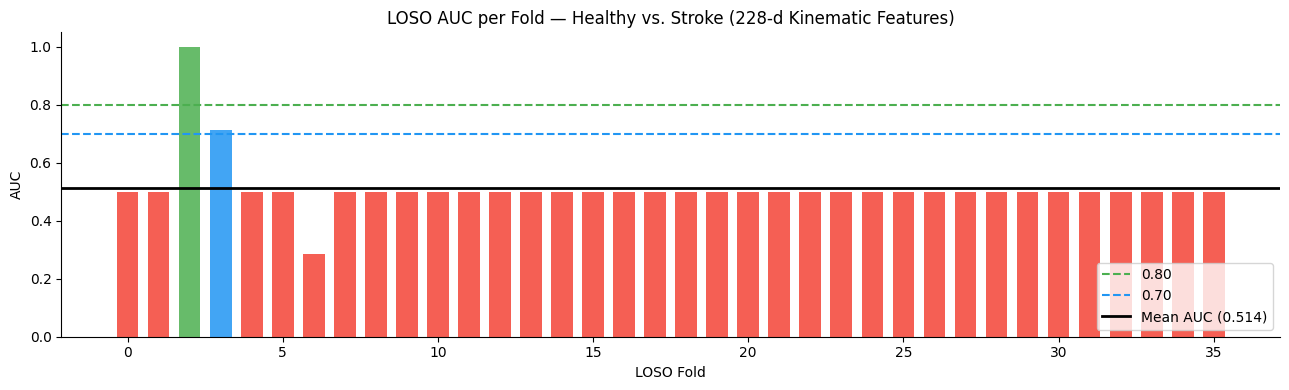

In [27]:
fig, ax = plt.subplots(figsize=(13, 4))
colors = ['#4CAF50' if a >= 0.8 else '#2196F3' if a >= 0.7
          else '#FF9800' if a >= 0.6 else '#F44336' for a in aucs]
ax.bar(range(len(aucs)), aucs, color=colors, alpha=0.85, width=0.7)
ax.axhline(0.8, color='#4CAF50', ls='--', lw=1.5, label='0.80')
ax.axhline(0.7, color='#2196F3', ls='--', lw=1.5, label='0.70')
ax.axhline(np.mean(aucs), color='black', ls='-', lw=2,
           label=f'Mean AUC ({np.mean(aucs):.3f})')
ax.set_xlabel('LOSO Fold')
ax.set_ylabel('AUC')
ax.set_title('LOSO AUC per Fold — Healthy vs. Stroke (228-d Kinematic Features)')
ax.set_ylim(0, 1.05)
ax.legend(loc='lower right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/baseline_loso_auc.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6 — Embedding Visualization (UMAP)

UMAP projects the 228-d feature space to 2D. Three views:
1. Colored by group (healthy vs. stroke) — shows class separation
2. Colored by ARAT score (continuous) — shows clinical score gradient in the embedding
3. Colored by subject — checks that visits from the same subject cluster together (expected) without perfect separation across subjects (which would indicate subject-level leakage)

In [28]:
import umap as umap_lib

d       = np.load(OUTPUT_PATH, allow_pickle=True)
X_um    = np.ascontiguousarray(d['features'], dtype=np.float32)
y_um    = d['labels'].astype(int)
arat_um = d['arat'].astype(np.float32)
pids_um = d['pids'].astype(int)

t0 = time.time()
reducer = umap_lib.UMAP(n_components=2, n_neighbors=15, min_dist=0.1,
                        metric='euclidean', random_state=42, n_jobs=-1)
emb = reducer.fit_transform(X_um)
print(f'UMAP done in {time.time()-t0:.1f}s')

UMAP done in 0.7s


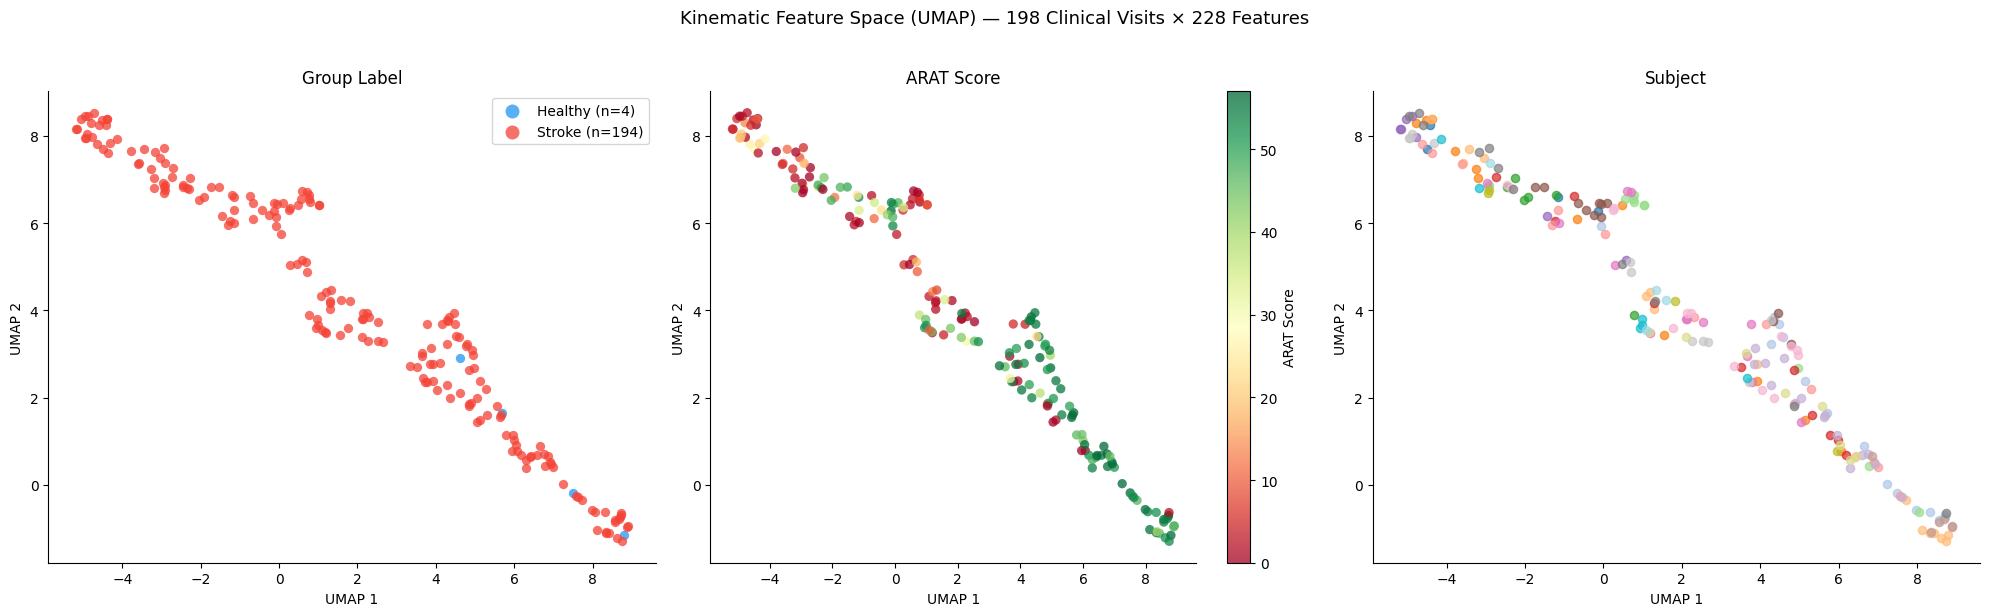

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# ---- Plot 1: Healthy vs Stroke ----
ax = axes[0]
for label, color, name in [(0, '#2196F3', 'Healthy'), (1, '#F44336', 'Stroke')]:
    mask = y_um == label
    ax.scatter(emb[mask, 0], emb[mask, 1], c=color,
               label=f'{name} (n={mask.sum()})', alpha=0.75, s=45, linewidths=0)
ax.set_title('Group Label', fontsize=12)
ax.set_xlabel('UMAP 1'); ax.set_ylabel('UMAP 2')
ax.legend(fontsize=10, markerscale=1.5)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# ---- Plot 2: ARAT gradient ----
ax = axes[1]
sc = ax.scatter(emb[:, 0], emb[:, 1], c=arat_um, cmap='RdYlGn',
                alpha=0.75, s=45, linewidths=0, vmin=0, vmax=57)
plt.colorbar(sc, ax=ax, label='ARAT Score')
ax.set_title('ARAT Score', fontsize=12)
ax.set_xlabel('UMAP 1'); ax.set_ylabel('UMAP 2')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# ---- Plot 3: By subject ----
ax = axes[2]
cmap = plt.cm.get_cmap('tab20', len(np.unique(pids_um)))
for i, pid in enumerate(np.unique(pids_um)):
    mask = pids_um == pid
    ax.scatter(emb[mask, 0], emb[mask, 1], color=cmap(i), alpha=0.7, s=35)
ax.set_title('Subject', fontsize=12)
ax.set_xlabel('UMAP 1'); ax.set_ylabel('UMAP 2')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plt.suptitle('Kinematic Feature Space (UMAP) — 198 Clinical Visits × 228 Features',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/umap_feature_space.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7 — Output Summary

In [30]:
d   = np.load(OUTPUT_PATH, allow_pickle=True)
res = pd.read_csv(f'{METRICS_DIR}/baseline_loso_results.csv')

checks = [
    ('features/biopm_features.npz exists', os.path.exists(OUTPUT_PATH)),
    ('features shape (198, 228)',          d['features'].shape == (198, 228)),
    ('features_even/odd shape OK',         d['features_even'].shape == (198, 228)),
    ('No NaNs',                            not np.isnan(d['features']).any()),
    ('Binary labels present',              len(set(d['labels'].tolist())) == 2),
    ('ARAT / FMA / weeks saved',           all(k in d for k in ['arat', 'fma', 'weeks'])),
    ('UMAP figure saved',                  os.path.exists(f'{FIGURES_DIR}/umap_feature_space.png')),
    ('Baseline metrics saved',             os.path.exists(f'{METRICS_DIR}/baseline_loso_results.csv')),
]

for name, result in checks:
    print(f'  [{"OK" if result else "FAIL"}]  {name}')

print(f"""
Output: {OUTPUT_PATH}
  features       {d['features'].shape}    kinematic feature matrix
  features_even  {d['features_even'].shape}    even 30-min blocks
  features_odd   {d['features_odd'].shape}    odd 30-min blocks
  labels         {d['labels'].shape}         0=healthy, 1=stroke
  pids           {d['pids'].shape}         subject ID for LOSO
  arat / fma     {d['arat'].shape}         clinical scores
  subjects       {d['subjects'].shape}         original subject IDs
  weeks          {d['weeks'].shape}         visit week number

Baseline LOSO (binary, healthy vs stroke):
  AUC  {res.auc.mean():.3f} +/- {res.auc.std():.3f}
  F1   {res.f1.mean():.3f} +/- {res.f1.std():.3f}

Note: low AUC is expected given 4 healthy vs 194 stroke visits.
Downstream analysis should use ARAT/FMA regression, not binary classification.
""")

  [OK]  features/biopm_features.npz exists
  [OK]  features shape (198, 228)
  [OK]  features_even/odd shape OK
  [OK]  No NaNs
  [OK]  Binary labels present
  [OK]  ARAT / FMA / weeks saved
  [OK]  UMAP figure saved
  [OK]  Baseline metrics saved

Output: features/biopm_features.npz
  features       (198, 228)    kinematic feature matrix
  features_even  (198, 228)    even 30-min blocks
  features_odd   (198, 228)    odd 30-min blocks
  labels         (198,)         0=healthy, 1=stroke
  pids           (198,)         subject ID for LOSO
  arat / fma     (198,)         clinical scores
  subjects       (198,)         original subject IDs
  weeks          (198,)         visit week number

Baseline LOSO (binary, healthy vs stroke):
  AUC  0.514 +/- 0.098
  F1   0.925 +/- 0.189

Note: low AUC is expected given 4 healthy vs 194 stroke visits.
Downstream analysis should use ARAT/FMA regression, not binary classification.

